# Decision Tree Regressor

### What is Decision Tree Regressor?

* **A Decision Tree Regressor is used to predict continuous values such as prices or scores using a tree-like structure.**
* **It splits the data into smaller groups based on simple rules derived from input features, helping reduce prediction errors.**
 * **At the end of each branch, called a leaf node, the model outputs a value, i.e., usually the average of that group.**

### Example:
**For example, to predict house prices using features like size, location, and age, the tree may first split by location, then by size and finally by age.**

### TASK:

In [17]:
from Day_10.scripts.non_linear_task import X_new, y, X
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeRegressor



In [18]:
# Train a Decision Tree
tree_reg = DecisionTreeRegressor(max_depth=3) #max_depth=3 which controls the maximum levels a tree can reach , controlling model complexity.
tree_reg.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

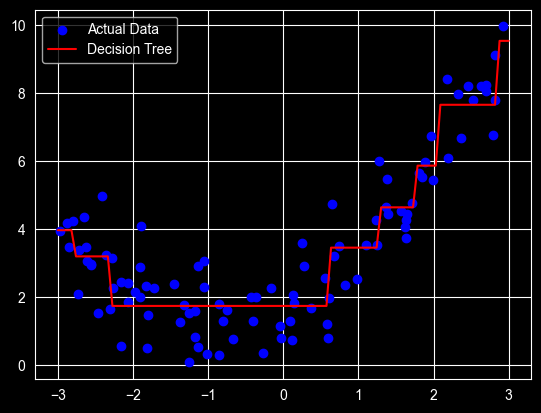

In [19]:
# Predict and see how it differs from the curve
y_tree_pred = tree_reg.predict(X_new)
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_new, y_tree_pred, color='red', label='Decision Tree')
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error

y_pred = tree_reg.predict(X)

mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error of Decision Tree Regressor: {mse:.4f}")

Mean Squared Error of Decision Tree Regressor: 0.6531


In [26]:
from Day_10.scripts.non_linear_task import model, X_poly
from sklearn.metrics import r2_score

# Polynomial R2
y_poly_pred = model.predict(X_poly)
r2_poly = r2_score(y, y_poly_pred)

# Decision Tree R2
y_tree_pred = tree_reg.predict(X)  # use trained tree
r2_tree = r2_score(y, y_tree_pred)

print(f"Polynomial R2 Score: {r2_poly:.4f}")
print(f"Decision Tree R2 Score: {r2_tree:.4f}")

Polynomial R2 Score: 0.8525
Decision Tree R2 Score: 0.8761


#### Observation:

**The Decision Tree achieves a higher R² score, indicating a better fit to the training data. However, the Polynomial model provides a smoother approximation and is likely to generalize better to unseen data.**

# SECTION 3: OVERFITTING (The "Memorization" Trap)

* If a Decision Tree is too deep (max_depth=None), it will memorize every single dot in your training data. This is called Overfitting.
* It looks perfect on your training data but fails miserably on new, unseen data.

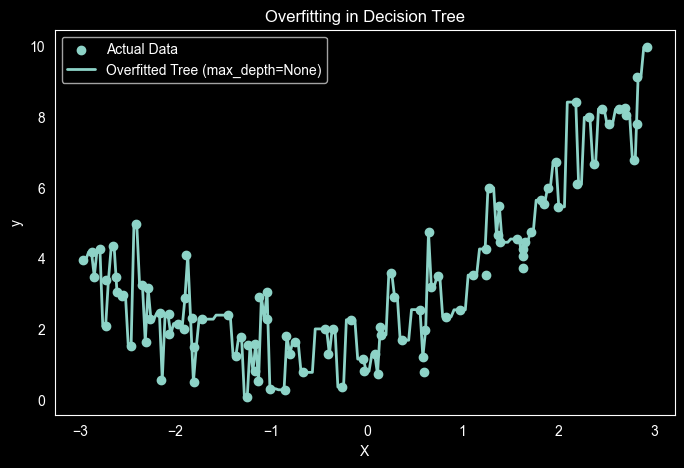

In [25]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

# Overfitted Tree
tree_overfit = DecisionTreeRegressor(max_depth=None)
tree_overfit.fit(X, y)

# Predictions
X_new = np.linspace(min(X), max(X), 200).reshape(-1, 1)
y_overfit = tree_overfit.predict(X_new)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, label="Actual Data")
plt.plot(X_new, y_overfit, linewidth=2, label="Overfitted Tree (max_depth=None)")

plt.title("Overfitting in Decision Tree")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()


plt.show()

#### Observation

* The model fits almost every data point exactly, indicating very low training error.
* The prediction curve is highly irregular and zig-zag, with many sharp jumps.
* Instead of capturing the overall trend, the model is memorizing noise in the data.
* The graph lacks smoothness and shows too many small step regions.
* The model creates very narrow splits, leading to overly complex decision boundaries.
* Although performance on training data is excellent, it will likely perform poorly on unseen data.
* This behavior is caused by max_depth=None, allowing unlimited tree growth.
* The model shows high variance and low bias, a classic sign of overfitting.

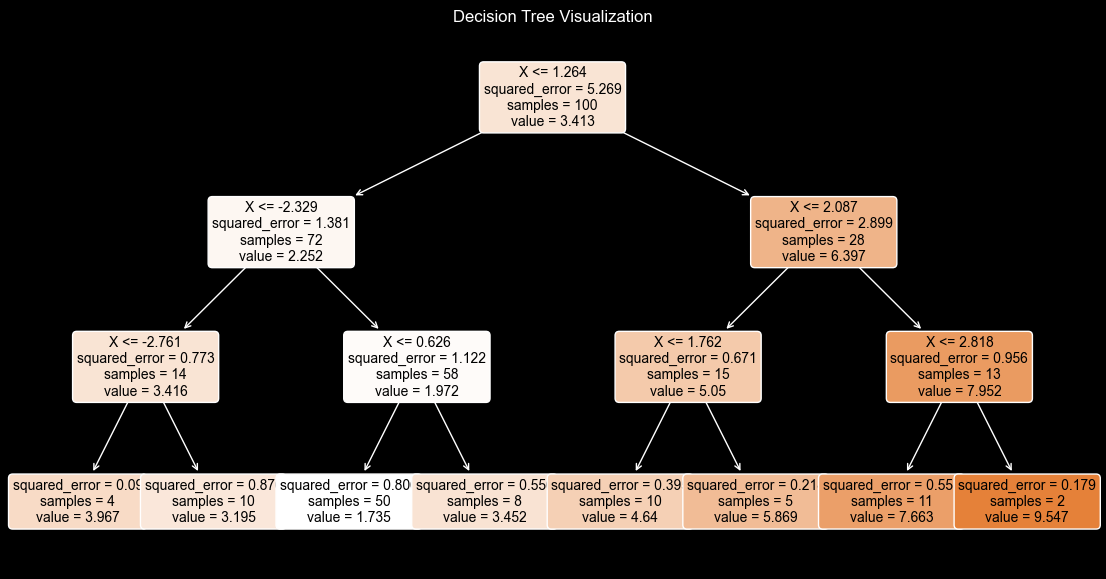

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

tree_plot = plot_tree(
    tree_reg,
    filled=True,
    feature_names=["X"],
    rounded=True,
    fontsize=10
)

# 🔥 Force all text to black
for text in plt.gca().texts:
    text.set_color("black")

plt.title("Decision Tree Visualization")
plt.show()

#### Observation:
* The Decision Tree splits the data using conditions on X and assigns a constant value to each region. It creates a step-like prediction instead of a smooth curve.

* Each node represents a decision rule, and the leaf nodes give the final predicted value. The model works by dividing the data into smaller regions to reduce error.

* The left side of the tree predicts lower values, while the right side predicts higher values. This shows how the model captures the relationship between X and Y using simple rules.